# Zadanie obowiązkowe [0-10] pkt

1. [0-0.5 pkt] Użyj zbalansowania klas w regresji logistycznej (parametr `class_weight`). Porównaj z modelem podstawowym
1. [0-1 pkt] Porównaj różne techniki podpróbkownia (*undersampling*). W szczególności (weź pod uwagę hiperparametry każdego podejścia!):
   1. *Undersampling* losowy
   2. [Cluster Centroids](https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.ClusterCentroids.html#clustercentroids)
   3. Edited Nearest Neighbours (patrz ćwiczenia) 
1. [0-2 pkt] Porównaj różne techniki nadpróbkowania (*oversampling*). W szczególności (weź pod uwagę hiperparametry każdego podejścia!):
   1. *Oversampling* losowy
   2. [SMOTE](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html)
   3. [Borderline SMOTE](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.BorderlineSMOTE.html#)
   3. [ADASYN](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.ADASYN.html)
1. [0-1 pkt] Przeprowadź *threshold tuning* tj. użyj innych progów odcięcia klasy pozytywnej w regresji logistycznej. Możesz wykorzystać np. metody opisane [tutaj](https://scikit-learn.org/stable/modules/classification_threshold.html). Optymalizuj względem AUPRC
1. [0-1 pkt] Użyj przynajmniej jednego innego klasyfikatora poznanego na zajęciach i porównaj jego wyniki z regresją logistyczną
1. [0-1.5 pkt] Zaimplementuj *focal loss* w `scikit-learn`. W tym celu, wyjątkowo, **możesz skorzystać z narzędzi generatywnej sztucznej inteligencji**
1. [0-2 pkt] Sporządź analizę porównawczą technik / modeli wyżej, uwzględniając podejścia podstawowe (*baseline*). Zwizualizuj krzywe ROC i PRC
1. [0-1 pkt] Skomentuj uzyskane wyniki

# 0. Import i wstępne przekształcenie danych

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo 
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from imblearn.under_sampling import EditedNearestNeighbours
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, precision_recall_curve

In [18]:
bank_marketing = fetch_ucirepo(id=222)
X = bank_marketing.data.features
y = bank_marketing.data.targets['y']

X_sel = X[['balance', 'duration', 'education']]

idx = X_sel.dropna().index
X_sel = X_sel.loc[idx]
y_sel = y.loc[idx]

label_encoder = LabelEncoder()
y_trans = label_encoder.fit_transform(y_sel.values)

enc = OneHotEncoder(drop='first', sparse_output=False)
education_encoded = enc.fit_transform(X_sel[['education']])
encoded_cols = enc.get_feature_names_out(['education'])
df_encoded = pd.DataFrame(education_encoded, columns=encoded_cols, index=X_sel.index)

X_trans = X_sel.drop(columns=['education']).join(df_encoded)

X_trans.columns = X_trans.columns.astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X_trans, y_trans, test_size=0.2, random_state=0
)

# 1. Porównanie zbalansowania klas w regresji logistycznej z modelem bazowym.

In [19]:
# Model bazowy
logreg_base = LogisticRegression(random_state=0)
logreg_base.fit(X_train, y_train)
y_pred_base = logreg_base.predict(X_test)

# Model z class_weight="balanced"
logreg_bal = LogisticRegression(random_state=0, class_weight='balanced')
logreg_bal.fit(X_train, y_train)
y_pred_bal = logreg_bal.predict(X_test)

In [20]:
def print_model_metrics(y_true, y_pred, model_name):
    print(f"Model: {model_name}")
    print(f"AUC: {roc_auc_score(y_true, y_pred):.2f}")
    print(f"AP: {average_precision_score(y_true, y_pred):.2f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print()

print_model_metrics(y_test, y_pred_base, "Logistic Regression (Base)")
print_model_metrics(y_test, y_pred_bal, "Logistic Regression (Balanced)")

Model: Logistic Regression (Base)
AUC: 0.57
AP: 0.18
Confusion Matrix:
[[7570  122]
 [ 825  154]]

Model: Logistic Regression (Balanced)
AUC: 0.73
AP: 0.24
Confusion Matrix:
[[6245 1447]
 [ 343  636]]



Zbalansowanie klas w regresji logistycznej znacznie poprawiło wyniki. Model z balansowaniem lepiej wykrywa rzadkie przypadki.

# 2. Porównanie technik próbkowania.

In [21]:
from imblearn.under_sampling import RandomUnderSampler, ClusterCentroids

In [22]:
def train_and_evaluate_sampler(sampler, sampler_name):
    X_res, y_res = sampler.fit_resample(X_train, y_train)

    logreg = LogisticRegression(random_state=0)
    logreg.fit(X_res, y_res)

    y_pred = logreg.predict(X_test)

    print_model_metrics(y_test, y_pred, f"Logistic Regression with {sampler_name} Sampler")

In [23]:
# RandomUnderSampler
rus = RandomUnderSampler(random_state=0)
train_and_evaluate_sampler(rus, "Random Undersampling")

# ClusterCentroids
cc = ClusterCentroids(random_state=0)
train_and_evaluate_sampler(cc, "Cluster Centroids")

# EditedNearestNeighbours
enn = EditedNearestNeighbours()
train_and_evaluate_sampler(enn, "Edited Nearest Neighbours")

Model: Logistic Regression with Random Undersampling Sampler
AUC: 0.73
AP: 0.24
Confusion Matrix:
[[6224 1468]
 [ 345  634]]

Model: Logistic Regression with Cluster Centroids Sampler
AUC: 0.65
AP: 0.16
Confusion Matrix:
[[5200 2492]
 [ 373  606]]

Model: Logistic Regression with Edited Nearest Neighbours Sampler
AUC: 0.67
AP: 0.24
Confusion Matrix:
[[7155  537]
 [ 573  406]]



Wyniki są do siebie zbliżone.

# 3. Porównanie technik nadpróbkowania.

In [24]:
from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE, ADASYN

In [25]:
# Losowy oversampling
ros = RandomOverSampler(random_state=0)
train_and_evaluate_sampler(ros, "Random Oversampling")

# SMOTE
smote = SMOTE(random_state=0)
train_and_evaluate_sampler(smote, "SMOTE")

# Borderline-SMOTE
bsmote = BorderlineSMOTE(random_state=0)
train_and_evaluate_sampler(bsmote, "Borderline SMOTE")

# ADASYN
adasyn = ADASYN(random_state=0)
train_and_evaluate_sampler(adasyn, "ADASYN")

Model: Logistic Regression with Random Oversampling Sampler
AUC: 0.73
AP: 0.24
Confusion Matrix:
[[6241 1451]
 [ 343  636]]

Model: Logistic Regression with SMOTE Sampler
AUC: 0.73
AP: 0.24
Confusion Matrix:
[[6204 1488]
 [ 340  639]]

Model: Logistic Regression with Borderline SMOTE Sampler
AUC: 0.73
AP: 0.24
Confusion Matrix:
[[6173 1519]
 [ 331  648]]

Model: Logistic Regression with ADASYN Sampler
AUC: 0.74
AP: 0.23
Confusion Matrix:
[[6038 1654]
 [ 305  674]]



Tutaj również wyniki każdej z metod są do siebie zbliżone.

# 4. Threshold tuning

In [26]:
from sklearn.metrics import f1_score

In [27]:
model = LogisticRegression(random_state=0)
model.fit(X_train, y_train)
y_probs = model.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

f1_scores = [] # f1 jest skorelowane z AUPRC i jest zależny od danego progu
for t in thresholds:
    y_pred = (y_probs >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred))

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

y_pred_tuned = (y_probs >= best_threshold).astype(int)

print(f"Najlepszy próg: {best_threshold:.3f}")
print(f"AUPRC (na prawdopodobieństwach): {average_precision_score(y_test, y_probs):.3f}")
print(f"F1-score przy najlepszym progu: {f1_score(y_test, y_pred_tuned):.3f}")
print("Macierz pomyłek:")
print(confusion_matrix(y_test, y_pred_tuned))

Najlepszy próg: 0.184
AUPRC (na prawdopodobieństwach): 0.376
F1-score przy najlepszym progu: 0.425
Macierz pomyłek:
[[6990  702]
 [ 525  454]]


# 5. Porównanie kNN z regresją logistyczną.

In [28]:
from sklearn.neighbors import KNeighborsClassifier

In [29]:
# Regresja logistyczna
logreg = LogisticRegression(random_state=0)
logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict(X_test)
print_model_metrics(y_test, y_pred_logreg, "Regresja logistyczna")

# K-Nearest Neighbors (k=5)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print_model_metrics(y_test, y_pred_knn, "k-NN (k=5)")

Model: Regresja logistyczna
AUC: 0.57
AP: 0.18
Confusion Matrix:
[[7570  122]
 [ 825  154]]

Model: k-NN (k=5)
AUC: 0.59
AP: 0.18
Confusion Matrix:
[[7418  274]
 [ 775  204]]



Wyniki są do siebie zbliżone.

# 6. Implementacja focal loss.

In [30]:
from sklearn.preprocessing import StandardScaler
from scipy.optimize import minimize

In [31]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def focal_loss(w, X, y, gamma=2.0, alpha=0.25):
    z = X @ w
    p = sigmoid(z)
    pt = np.where(y == 1, p, 1 - p)
    loss = -alpha * (1 - pt) ** gamma * np.log(pt + 1e-8)
    return np.mean(loss)

def focal_loss_grad(w, X, y, gamma=2.0, alpha=0.25):
    z = X @ w
    p = sigmoid(z)
    pt = np.where(y == 1, p, 1 - p)
    dpt_dz = p * (1 - p) * np.where(y == 1, 1, -1)
    coeff = -alpha * gamma * (1 - pt) ** (gamma - 1) * np.log(pt + 1e-8) - alpha * (1 - pt) ** gamma / (pt + 1e-8)
    grad = (coeff * dpt_dz).reshape(-1, 1) * X
    return grad.mean(axis=0)

X_scaled = StandardScaler().fit_transform(X_train)
X_with_bias = np.hstack([np.ones((X_scaled.shape[0], 1)), X_scaled])
y = y_train

res = minimize(
    fun=focal_loss,
    x0=np.zeros(X_with_bias.shape[1]),
    args=(X_with_bias, y),
    jac=focal_loss_grad,
    method="L-BFGS-B"
)

X_test_scaled = StandardScaler().fit(X_train).transform(X_test)
X_test_with_bias = np.hstack([np.ones((X_test_scaled.shape[0], 1)), X_test_scaled])
y_proba = sigmoid(X_test_with_bias @ res.x)
y_pred = (y_proba >= 0.5).astype(int)

print("Focal Loss – wyniki")
print("AUPRC:", average_precision_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Focal Loss – wyniki
AUPRC: 0.11290508591857917
ROC AUC: 0.5
Confusion Matrix:
[[   0 7692]
 [   0  979]]


Wyniki sugerują, że implemntacja jest niepoprawna.

# 7. Analiza porównawcza modeli.

In [32]:
from sklearn.metrics import roc_curve

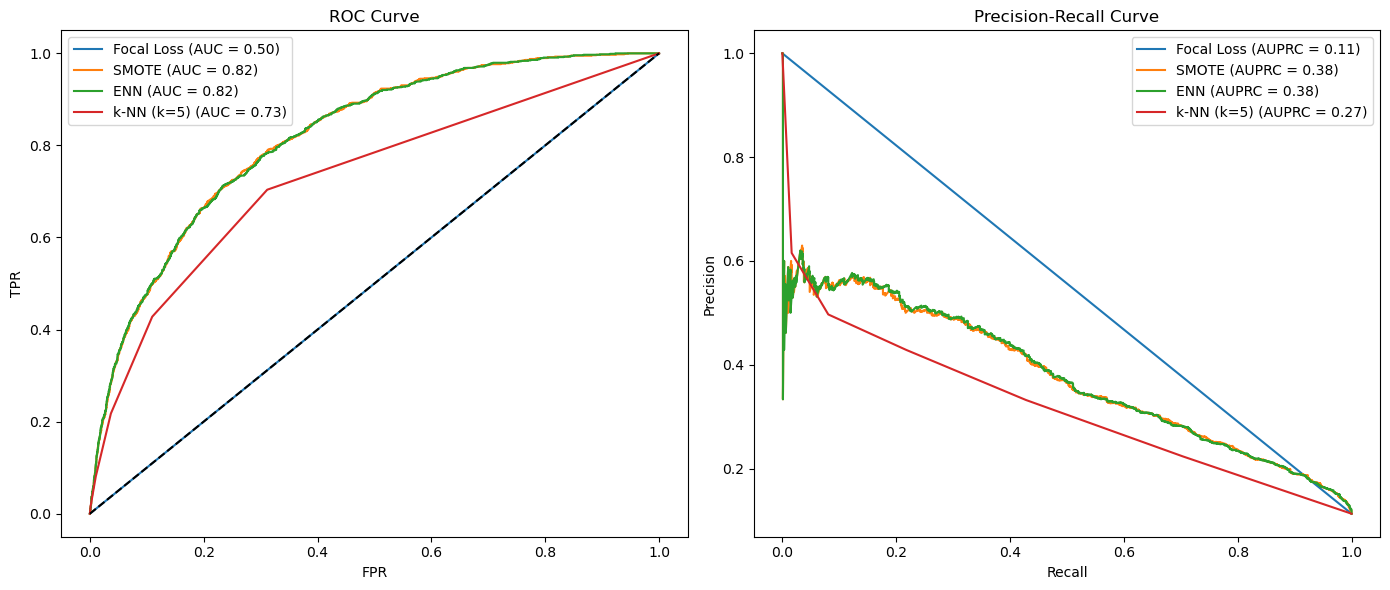

In [33]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Focal Loss
def sigmoid(x): return 1 / (1 + np.exp(-x))

def focal_loss(w, X, y, gamma=2.0, alpha=0.25):
    z = X @ w
    p = sigmoid(z)
    pt = np.where(y == 1, p, 1 - p)
    return np.mean(-alpha * (1 - pt) ** gamma * np.log(pt + 1e-8))

def focal_grad(w, X, y, gamma=2.0, alpha=0.25):
    z = X @ w
    p = sigmoid(z)
    pt = np.where(y == 1, p, 1 - p)
    dpt_dz = p * (1 - p) * np.where(y == 1, 1, -1)
    coeff = -alpha * gamma * (1 - pt) ** (gamma - 1) * np.log(pt + 1e-8) - alpha * (1 - pt) ** gamma / (pt + 1e-8)
    grad = (coeff * dpt_dz).reshape(-1, 1) * X
    return grad.mean(axis=0)

X_focal = np.hstack([np.ones((X_train_scaled.shape[0], 1)), X_train_scaled])
X_test_focal = np.hstack([np.ones((X_test_scaled.shape[0], 1)), X_test_scaled])

res = minimize(
    fun=focal_loss,
    x0=np.zeros(X_focal.shape[1]),
    args=(X_focal, y_train),
    jac=focal_grad,
    method="L-BFGS-B"
)
y_proba_focal = sigmoid(X_test_focal @ res.x)

# SMOTE
smote = SMOTE(random_state=0)
X_smote, y_smote = smote.fit_resample(X_train_scaled, y_train)
model_smote = LogisticRegression().fit(X_smote, y_smote)
y_proba_smote = model_smote.predict_proba(X_test_scaled)[:, 1]

# ENN
enn = EditedNearestNeighbours()
X_enn, y_enn = enn.fit_resample(X_train_scaled, y_train)
model_enn = LogisticRegression().fit(X_enn, y_enn)
y_proba_enn = model_enn.predict_proba(X_test_scaled)[:, 1]

# k-NN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_proba_knn = knn.predict_proba(X_test_scaled)[:, 1]

models = {
    "Focal Loss": y_proba_focal,
    "SMOTE": y_proba_smote,
    "ENN": y_proba_enn,
    "k-NN (k=5)": y_proba_knn
}

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
for name, y_proba in models.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()

plt.subplot(1, 2, 2)
for name, y_proba in models.items():
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    auprc = average_precision_score(y_test, y_proba)
    plt.plot(recall, precision, label=f"{name} (AUPRC = {auprc:.2f})")
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()

plt.tight_layout()
plt.show()

# 8. Komentarz do wyników

Najlepsze wyniki osiągnęły modele trenowane z użyciem SMOTE oraz Edited Nearest Neighbours (ENN). Obie techniki dostarczyły bardzo zbliżone wyniki, zarówno pod względem ROC (0.82), jak i AUPRC (0.38), co świadczy o ich wysokiej skuteczności w zadaniu klasyfikacji danych niezbalansowanych.

Model oparty na k-NN (k = 5) wypadł zauważalnie gorzej. 

Z kolei model trenowany z wykorzystaniem focal loss uzyskał wyniki zbliżone do klasyfikatora losowego, co sugeruje, że jego implementacja jest niepoprawna.